# LambdaLLG 2D DMI Skyrmion Test

This notebook exercises the new 2D DMI term with three qualitative checks:

1. Bulk DMI with bond-parallel Moriya vectors stabilizes a **Bloch** skyrmion.
2. Interfacial DMI with `D = ((0, D, 0), (-D, 0, 0))` stabilizes a **Neel** skyrmion.
3. Starting from the relaxed interfacial skyrmion, turning **DMI off** and applying a field aligned with the core inflates it into a circular bubble that reaches the edge and loses its topological charge.

The parameter sets below were tuned for a clear qualitative demonstration rather than for material realism.


In [1]:
using Pkg; Pkg.activate("../")


  Activating project at `C:\Users\freye\PersonalCode\LambdaLLG.jl`


In [2]:
using LambdaLLG
using LinearAlgebra
using Statistics
import PyPlot as plt


## Helpers

The skyrmion seed is built from a radial wall profile. We also compute a simple finite-difference topological charge and a wall-helicity summary:

- **Bloch** textures should have larger tangential than radial in-plane weight.
- **Neel** textures should have larger radial than tangential in-plane weight.


In [28]:
function normalize_spins!(spins)
    Nx, Ny = size(spins, 2), size(spins, 3)
    for j in 1:Ny, i in 1:Nx
        spins[:, i, j] ./= norm(view(spins, :, i, j))
    end
    return spins
end

function skyrmion_seed(Nx, Ny; radius=10.0, width=3.0, kind=:neel, chirality=1.0, polarity=-1.0)
    s0 = zeros(3, Nx, Ny)
    x0 = (Nx + 1) / 2
    y0 = (Ny + 1) / 2

    for j in 1:Ny, i in 1:Nx
        dx = i - x0
        dy = j - y0
        r = hypot(dx, dy)
        mz = polarity * tanh((radius - r) / width)
        mxy = sqrt(max(0.0, 1.0 - mz^2))

        if r < 1e-12
            mx = 0.0
            my = 0.0
        elseif kind == :neel
            mx = chirality * mxy * dx / r
            my = chirality * mxy * dy / r
        elseif kind == :bloch
            mx = -chirality * mxy * dy / r
            my = chirality * mxy * dx / r
        else
            error("unknown skyrmion kind")
        end

        s0[:, i, j] .= (mx, my, mz)
    end

    return normalize_spins!(s0)
end

function topological_charge(spins)
    Nx, Ny = size(spins, 2), size(spins, 3)
    q = 0.0
    for j in 2:Ny-1, i in 2:Nx-1
        sx = 0.5 .* (spins[:, i + 1, j] .- spins[:, i - 1, j])
        sy = 0.5 .* (spins[:, i, j + 1] .- spins[:, i, j - 1])
        q += dot(spins[:, i, j], cross(sx, sy))
    end
    return q / (4pi)
end

core_radius(spins; threshold=0.0) = sqrt(count(<(threshold), spins[3, :, :]) / pi)

function chirality_summary(spins; mz_window=0.25)
    Nx, Ny = size(spins, 2), size(spins, 3)
    x0 = (Nx + 1) / 2
    y0 = (Ny + 1) / 2
    radial = Float64[]
    tangential = Float64[]

    for j in 1:Ny, i in 1:Nx
        mz = spins[3, i, j]
        if abs(mz) < mz_window
            dx = i - x0
            dy = j - y0
            r = hypot(dx, dy)
            if r > 1e-12
                ex = dx / r
                ey = dy / r
                mx, my = spins[1, i, j], spins[2, i, j]
                push!(radial, mx * ex + my * ey)
                push!(tangential, -mx * ey + my * ex)
            end
        end
    end

    if isempty(radial)
        return (
            wall_points = 0,
            mean_radial = 0.0,
            mean_tangential = 0.0,
            mean_abs_radial = 0.0,
            mean_abs_tangential = 0.0,
        )
    end

    return (
        wall_points = length(radial),
        mean_radial = mean(radial),
        mean_tangential = mean(tangential),
        mean_abs_radial = mean(abs.(radial)),
        mean_abs_tangential = mean(abs.(tangential)),
    )
end

function texture_summary(spins)
    Nx, Ny = size(spins, 2), size(spins, 3)
    cx = Int(round((Nx + 1) / 2))
    cy = Int(round((Ny + 1) / 2))
    helicity = chirality_summary(spins)
    return (
        Q = topological_charge(spins),
        radius = core_radius(spins),
        center_spin = spins[:, cx, cy],
        wall_points = helicity.wall_points,
        mean_abs_radial = helicity.mean_abs_radial,
        mean_abs_tangential = helicity.mean_abs_tangential,
    )
end

function radius_series(sol, Nx, Ny)
    return [core_radius(reshape(u, 3, Nx, Ny)) for u in sol.u]
end

function plot_texture!(ax, spins; stride=4, title="")
    mz = spins[3, :, :]
    Nx, Ny = size(spins, 2), size(spins, 3)
    xs = 1:stride:Nx
    ys = 1:stride:Ny
    X = [i for j in ys, i in xs]
    Y = [j for j in ys, i in xs]
    U = [spins[1, i, j] for j in ys, i in xs]
    V = [spins[2, i, j] for j in ys, i in xs]

    im = ax.pcolormesh(mz, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.quiver(X, Y, U, V, color="lightgreen", pivot="mid", scale=20, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    return im
end


plot_texture! (generic function with 1 method)

## 1. Bulk DMI selects a Bloch skyrmion

For the bond-parallel 2D bulk DMI choice

`D_bulk = ((D, 0, 0), (0, D, 0))`

a Bloch seed with the matching chirality should remain topological after relaxation, and the wall should stay predominantly **tangential**.


In [66]:
Nx = 101
Ny = 101
J = 1.0
alpha = 0.3

K_bulk = (0.0, 0.0, 0.45)
D_bulk = ((0.25, 0.0, 0.0), (0.0, 0.25, 0.0))

s_bloch0 = skyrmion_seed(Nx, Ny; radius=10.0, width=2.8, kind=:bloch, chirality=-1.0, polarity=-1.0)
p_bulk = LLGParams2D(Nx, Ny, J, K_bulk, (0.0, 0.0, 0.0), alpha; D=D_bulk)
sol_bulk = evolve2D(copy(s_bloch0), (0.0, 120.0), p_bulk; reltol=1e-6, abstol=1e-6)
s_bulk = reshape(copy(sol_bulk.u[end]), 3, Nx, Ny)
bulk_summary = texture_summary(s_bulk)
display(bulk_summary)


(Q = -0.9125403788495141, radius = 9.91754782346883, center_spin = [-5.364256361990944e-13, -2.3813153999105017e-13, -1.0], wall_points = 44, mean_abs_radial = 0.3165670836984582, mean_abs_tangential = 0.9428290550405058)

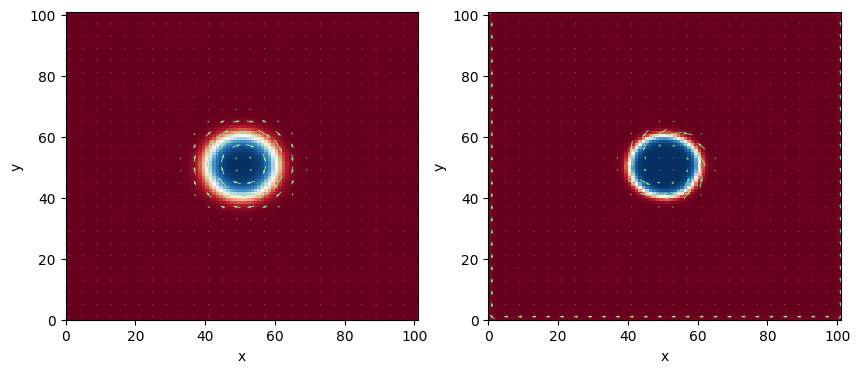

PyObject <matplotlib.collections.QuadMesh object at 0x00000294F631B390>

In [67]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

plot_texture!(ax[1], s_bloch0)
plot_texture!(ax[2], s_bulk)

## 2. Interfacial DMI selects a Neel skyrmion

For the interfacial DMI choice

`D_int = ((0, D, 0), (-D, 0, 0))`

a Neel seed with the matching chirality should relax to a compact topological texture with dominant **radial** wall magnetization.


In [70]:
K_int = (0.0, 0.0, 0.15)
D_int = ((0.0, 0.2, 0.0), (-0.2, 0.0, 0.0))

s_neel0 = skyrmion_seed(Nx, Ny; radius=10.0, width=2.8, kind=:neel, chirality=1.0, polarity=-1.0)
p_int = LLGParams2D(Nx, Ny, J, K_int, (0.0, 0.0, 0.0), alpha; D=D_int)
sol_int = evolve2D(copy(s_neel0), (0.0, 120.0), p_int; reltol=1e-6, abstol=1e-6)
s_int = reshape(copy(sol_int.u[end]), 3, Nx, Ny)
int_summary = texture_summary(s_int)
display(int_summary)


(Q = -0.9352944612338696, radius = 21.38717621487482, center_spin = [1.7810118445286887e-13, 1.0455056766364205e-12, -1.0], wall_points = 164, mean_abs_radial = 0.989498811584118, mean_abs_tangential = 0.030527513994077965)

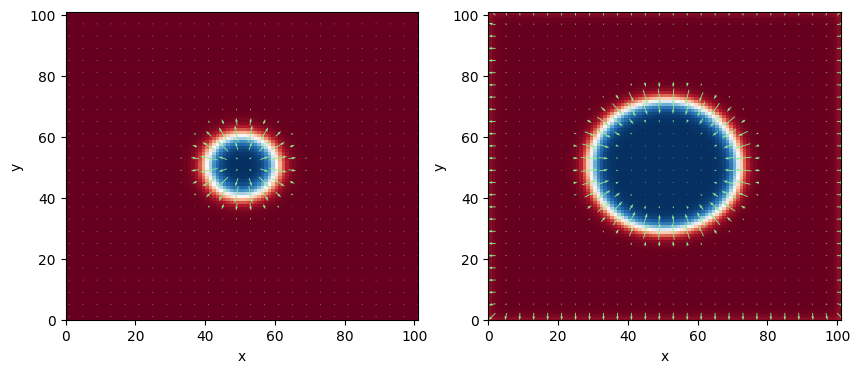

PyObject <matplotlib.collections.QuadMesh object at 0x00000296CEFB6D50>

In [71]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

plot_texture!(ax[1], s_neel0)
plot_texture!(ax[2], s_int)

## 3. Turn off DMI and let the field inflate the skyrmion bubble

We now start from the **relaxed interfacial skyrmion**, set `D = 0`, and apply a field along the skyrmion-core direction.

In this regime the compact chiral skyrmion is no longer protected by DMI. The reversed domain expands into a large circular bubble, reaches the edge of the finite sample, and the topological charge collapses toward zero.


In [96]:
p_bubble = LLGParams2D(
    Nx,
    Ny,
    J,
    K_int,
    (0.0, 0.0, -0.1),
    alpha;
    D=((0.0, 0.0, 0.0), (0.0, 0.0, 0.0)),
)

sol_bubble = evolve2D(copy(s_int), (0.0, 800.0), p_bubble; reltol=1e-6, abstol=1e-6)
s_bubble_final = reshape(copy(sol_bubble.u[end]), 3, Nx, Ny)

bubble_radii = radius_series(sol_bubble, Nx, Ny)
bubble_q_idx = 1:20:length(sol_bubble.u)
bubble_q_t = sol_bubble.t[bubble_q_idx]
bubble_q = [topological_charge(reshape(sol_bubble.u[k], 3, Nx, Ny)) for k in bubble_q_idx]

(
    initial = texture_summary(reshape(sol_bubble.u[1], 3, Nx, Ny)),
    final = texture_summary(s_bubble_final),
)


(initial = (Q = -0.9352944612338696, radius = 21.38717621487482, center_spin = [1.7810118445286887e-13, 1.0455056766364205e-12, -1.0], wall_points = 164, mean_abs_radial = 0.989498811584118, mean_abs_tangential = 0.030527513994077965), final = (Q = -2.7863190268045165e-9, radius = 56.983147938323384, center_spin = [-6.2910836500622454e-9, -1.65451550168129e-8, -0.9999999999999999], wall_points = 0, mean_abs_radial = 0.0, mean_abs_tangential = 0.0))

## 4. Plots

The center-line plots use the requested spin-component colors: **blue** for `m_x`, **green** for `m_y`, and **red** for `m_z`.


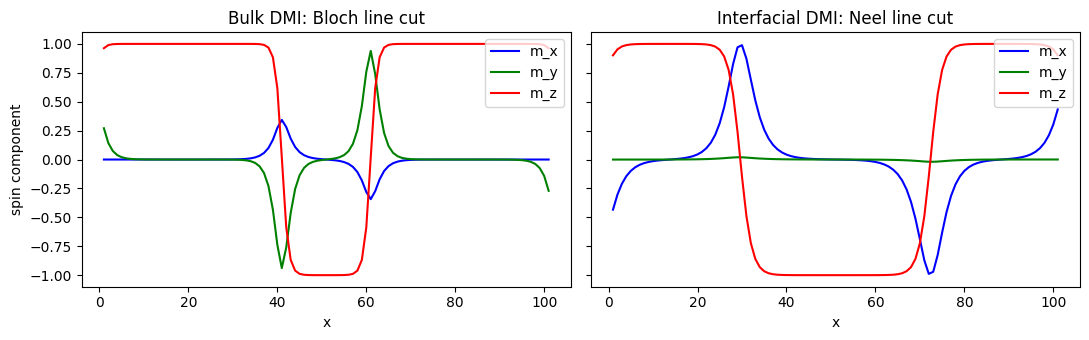

In [97]:
cy = Int(round((Ny + 1) / 2))
x = 1:Nx

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5), sharey=true)

ax[1].plot(x, s_bulk[1, :, cy], color="blue", label="m_x")
ax[1].plot(x, s_bulk[2, :, cy], color="green", label="m_y")
ax[1].plot(x, s_bulk[3, :, cy], color="red", label="m_z")
ax[1].set_title("Bulk DMI: Bloch line cut")
ax[1].set_xlabel("x")
ax[1].set_ylabel("spin component")
ax[1].legend(loc="upper right")

ax[2].plot(x, s_int[1, :, cy], color="blue", label="m_x")
ax[2].plot(x, s_int[2, :, cy], color="green", label="m_y")
ax[2].plot(x, s_int[3, :, cy], color="red", label="m_z")
ax[2].set_title("Interfacial DMI: Neel line cut")
ax[2].set_xlabel("x")
ax[2].legend(loc="upper right")

plt.tight_layout()


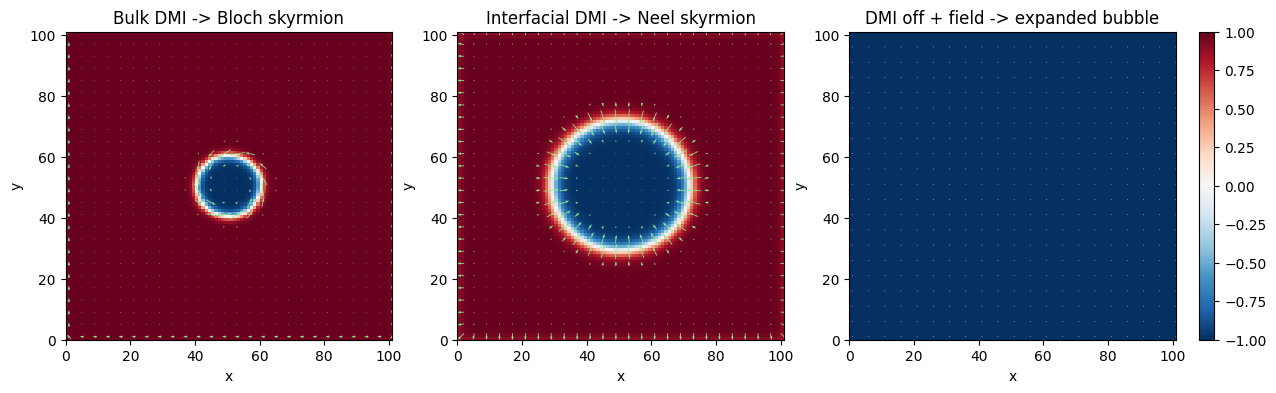

PyObject <matplotlib.colorbar.Colorbar object at 0x0000029968C17990>

In [98]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
im1 = plot_texture!(ax[1], s_bulk, title="Bulk DMI -> Bloch skyrmion")
im2 = plot_texture!(ax[2], s_int, title="Interfacial DMI -> Neel skyrmion")
im3 = plot_texture!(ax[3], s_bubble_final; stride=5, title="DMI off + field -> expanded bubble")
fig.colorbar(im3, ax=ax, fraction=0.025, pad=0.02)



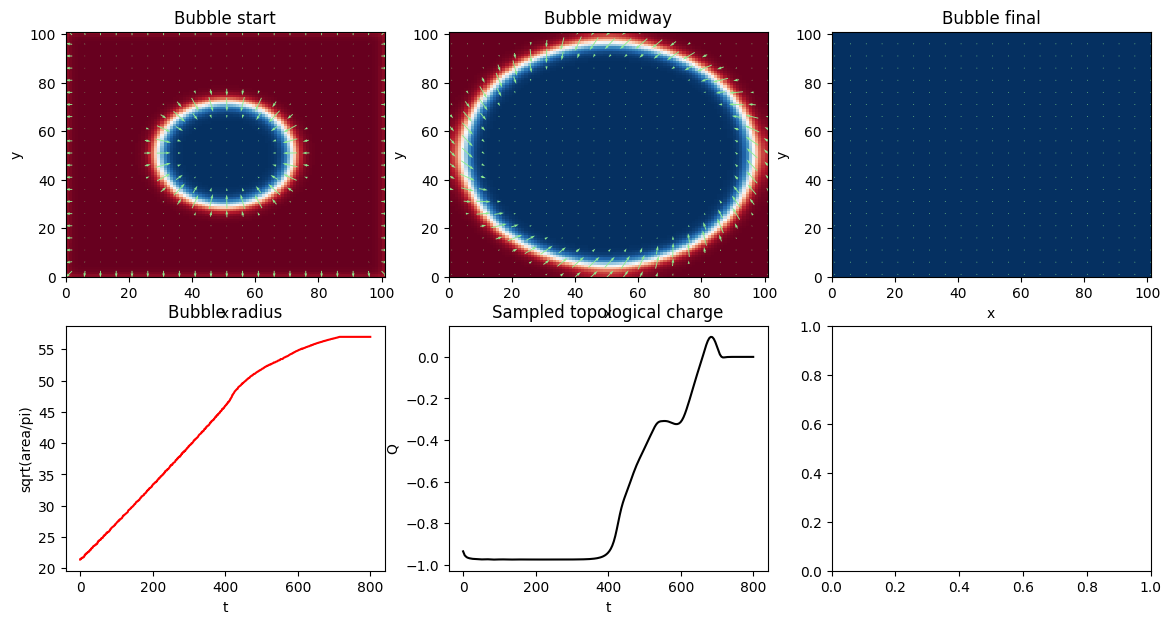

PyObject Text(399.6911764705883, 0.5, 'Q')

In [99]:
mid_idx = Int(cld(length(sol_bubble.u), 2))
s_bubble_mid = reshape(sol_bubble.u[mid_idx], 3, Nx, Ny)

fig, ax = plt.subplots(2, 3, figsize=(14, 7))

plot_texture!(ax[1, 1], reshape(sol_bubble.u[1], 3, Nx, Ny); stride=5, title="Bubble start")
plot_texture!(ax[1, 2], s_bubble_mid; stride=5, title="Bubble midway")
plot_texture!(ax[1, 3], s_bubble_final; stride=5, title="Bubble final")

ax[2, 1].plot(sol_bubble.t, bubble_radii, color="red")
ax[2, 1].set_title("Bubble radius")
ax[2, 1].set_xlabel("t")
ax[2, 1].set_ylabel("sqrt(area/pi)")

ax[2, 2].plot(bubble_q_t, bubble_q, color="black")
ax[2, 2].set_title("Sampled topological charge")
ax[2, 2].set_xlabel("t")
ax[2, 2].set_ylabel("Q")
